In [1]:
# !uv pip install quantities numpy matplotlib elephant scipy neo pyocclient tqdm

This session introduces the trial-by-trial variability of single neuron spike trains and its relation to interval variability. The exercises cover the time-resolved Fano factor and the comparison of interval and count variability in the context of stochastic point process theory. The module is designed for 2-3 hours of practical work and divides into two sections. Students present and discuss their results on individual sections at the end of class.

The data were kindly provided by Alexa Riehle, Institut de Neurosciences de la Timone (INT), Centre National de la Recherche Scientifique (CNRS) - Aix-Marseille Universite (AMU), UMR7289, 13005 Marseille, France. Use of this data outside of this teaching course is strictly prohibited. Data published under https://doi.org/10.12751/g-node.rz77m8.

## Setup

### Import Libraries

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import elephant.statistics
import elephant.spike_train_generation
%matplotlib inline


### Utility Functions

Run the cell below to load the utility functions used in the exercises.

In [2]:
class utils:
    @staticmethod
    def load_neuron(mo_path, ts_path=None):
        mat = scipy.io.loadmat(mo_path)
        sf  = mat['SparseFormat'][0, 0]
        dt  = float(sf['TimeResolutionMS'][0, 0])
        def parse(sf_field):
            interval = sf_field['CutIntervalMS'][0]
            t_start  = float(interval[0])
            t_stop   = float(interval[1])
            result   = []
            for d in range(sf_field['Data'].shape[1]):
                matrix = sf_field['Data'][0, d].toarray()
                sts    = []
                for trial in range(matrix.shape[1]):
                    idx = np.where(matrix[:, trial])[0]
                    sts.append(t_start + idx * dt)
                result.append(sts)
            return result, t_start, t_stop
        parsed, t_start, t_stop = parse(sf)
        out = {'mo': parsed, 't_start_ms': t_start, 't_stop_ms': t_stop}
        if ts_path is not None:
            mat2 = scipy.io.loadmat(ts_path)
            ts_parsed, ts_t_start, ts_t_stop = parse(mat2['SparseFormat'][0, 0])
            out['ts']           = ts_parsed
            out['ts_t_start_ms'] = ts_t_start
            out['ts_t_stop_ms']  = ts_t_stop
        return out

    @staticmethod
    def load_population(data_dir='data/'):
        """Load all C1-MO neurons in data_dir. Returns list of dicts from load_neuron()."""
        import glob
        paths = sorted(glob.glob(f'{data_dir}*-C1-MO.mat'))
        neurons = []
        for path in paths:
            try:
                neurons.append(utils.load_neuron(path))
            except Exception:
                pass
        print(f'Loaded {len(neurons)} neuron(s) from {data_dir}')
        return neurons

    @staticmethod
    def simulate_renewal_trains(rate_hz, shape_factor, n_trains, duration_s=2.0):
        """Simulate n Gamma(shape_factor) renewal trains. shape_factor=1 gives Poisson.
        Returns list of numpy arrays of spike times (ms)."""
        import quantities as pq
        if shape_factor == 1:
            proc = elephant.spike_train_generation.StationaryPoissonProcess(
                rate=rate_hz * pq.Hz, t_start=0 * pq.s, t_stop=duration_s * pq.s)
        else:
            proc = elephant.spike_train_generation.StationaryGammaProcess(
                rate=rate_hz * pq.Hz, shape_factor=shape_factor,
                t_start=0 * pq.s, t_stop=duration_s * pq.s)
        return [st.rescale(pq.ms).magnitude for st in proc.generate_n_spiketrains(n_trains)]

    @staticmethod
    def simulate_doubly_stochastic(rates_hz, duration_s=2.0):
        """One stationary Poisson train per rate in rates_hz.
        Returns list of numpy arrays of spike times (ms)."""
        import quantities as pq
        return [elephant.spike_train_generation.StationaryPoissonProcess(
                    rate=r * pq.Hz, t_start=0 * pq.s, t_stop=duration_s * pq.s)
                .generate_spiketrain().rescale(pq.ms).magnitude
                for r in rates_hz]

    @staticmethod
    def count_in_window(sts, t1_ms, t2_ms):
        return np.array([np.sum((st >= t1_ms) & (st < t2_ms)) for st in sts])

    @staticmethod
    def compute_ff_timecourse(sts, W_ms, t_start_ms, t_stop_ms, step_ms=10):
        """Sliding-window Fano factor. Returns (t_centres_ms, ff_values)."""
        t_pts   = np.arange(t_start_ms, t_stop_ms - W_ms, step_ms)
        ff_vals = []
        for t in t_pts:
            cnts = utils.count_in_window(sts, t, t + W_ms)
            m    = np.mean(cnts)
            ff_vals.append(np.var(cnts) / m if m > 0 else np.nan)
        return t_pts + W_ms / 2, np.array(ff_vals)

    # --- plotting utilities ---------------------------------------------------

    @staticmethod
    def plot_ff_timecourse(t_centres, ff_vals, label=None, ax=None):
        """Plot one FF time course. Creates a figure if ax is None."""
        if ax is None:
            _, ax = plt.subplots(figsize=(10, 3))
        ax.plot(t_centres, ff_vals, label=label)
        ax.axvline(0, color='r', ls='--', lw=0.8)
        ax.axhline(1.0, color='k', ls=':', lw=0.8)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Fano Factor')
        return ax

    @staticmethod
    def plot_ff_compare_windows(sts, ws, t_start, t_stop, step_ms=10):
        """FF traces for multiple window widths on one axes."""
        _, ax = plt.subplots(figsize=(10, 3))
        for W in ws:
            t_c, ff = utils.compute_ff_timecourse(sts, W, t_start, t_stop, step_ms)
            utils.plot_ff_timecourse(t_c, ff, label=f'W = {W} ms', ax=ax)
        ax.legend()

    @staticmethod
    def plot_ff_all_directions(sts_list, W_ms, t_start, t_stop, step_ms=10):
        """FF traces for all directions on one axes."""
        _, ax = plt.subplots(figsize=(10, 3))
        for d, sts in enumerate(sts_list):
            t_c, ff = utils.compute_ff_timecourse(sts, W_ms, t_start, t_stop, step_ms)
            utils.plot_ff_timecourse(t_c, ff, label=f'Dir {d}', ax=ax)
        ax.legend(fontsize=7)

    @staticmethod
    def plot_ff_alignment_comparison(sts_mo, sts_ts, W_ms,
                                      t_start_mo, t_stop_mo,
                                      t_start_ts, t_stop_ts,
                                      step_ms=10):
        """FF side by side for MO- and TS-aligned spike trains, each on its own time axis."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
        params = [
            (sts_mo, t_start_mo, t_stop_mo, 'MO-aligned'),
            (sts_ts, t_start_ts, t_stop_ts, 'TS-aligned'),
        ]
        for ax, (sts, t0, t1, label) in zip(axes, params):
            t_c, ff = utils.compute_ff_timecourse(sts, W_ms, t0, t1, step_ms)
            utils.plot_ff_timecourse(t_c, ff, label=label, ax=ax)
            ax.set_title(label)
            ax.legend()
        fig.tight_layout()

    @staticmethod
    def plot_ff_population_scatter(ff_arr, cv2sq_arr, labels=None):
        """Log-log scatter of FF vs CV2² with renewal diagonal. Optional point labels."""
        lim = [0.05, 20]
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(ff_arr, cv2sq_arr, s=20, alpha=0.5, color='steelblue')
        ax.plot(lim, lim, 'r-', lw=1.5, label='FF = CV2² (renewal)')
        if labels is not None:
            for label, ff, cv2sq in zip(labels, ff_arr, cv2sq_arr):
                ax.annotate(str(label), (ff, cv2sq), textcoords='offset points',
                            xytext=(4, 4), fontsize=9)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('FF'); ax.set_ylabel('CV2²')
        ax.legend()
        ax.set_title(f'n = {len(ff_arr)}')

    @staticmethod
    def plot_ff_with_marginals(ff_arr, cv2sq_arr):
        """Scatter plus marginal histograms of FF and CV2²."""
        lim  = [0.05, 20]
        bins = np.logspace(np.log10(lim[0]), np.log10(lim[1]), 25)
        fig, axes = plt.subplots(1, 3, figsize=(14, 5))
        ax = axes[0]
        ax.scatter(ff_arr, cv2sq_arr, s=15, alpha=0.5, color='steelblue')
        ax.plot(lim, lim, 'r-', lw=1.5, label='FF = CV2²')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('FF'); ax.set_ylabel('CV2²'); ax.legend(fontsize=9)
        axes[1].hist(ff_arr, bins=bins, color='steelblue', edgecolor='white')
        axes[1].set_xscale('log'); axes[1].set_xlim(lim)
        axes[1].set_xlabel('FF'); axes[1].set_ylabel('Count')
        axes[1].set_title('Marginal: FF')
        axes[2].hist(cv2sq_arr, bins=bins, color='coral', edgecolor='white')
        axes[2].set_xscale('log'); axes[2].set_xlim(lim)
        axes[2].set_xlabel('CV2²'); axes[2].set_ylabel('Count')
        axes[2].set_title('Marginal: CV2²')
        fig.tight_layout()


## Download Data

In [3]:
import os
import owncloud
from tqdm import tqdm

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/Tpc3YDYMpYdc53j', folder_password='ibots')

os.makedirs('data', exist_ok=True)
for f in tqdm(oc.list('/'), desc='Downloading Files to data/'):
    if not os.path.exists(f'data{f.path}'):
        oc.get_file(f.path, f'data{f.path}')

### Load Recording Data

In [4]:
data = utils.load_neuron('data/joe096-5-C1-MO.mat', 'data/joe096-5-C1-TS.mat')

## Time-Resolved Fano Factor

Neural activity is inherently variable across identical experimental repetitions, and this variability is typically high with respect to the trial-averaged mean response (Arieli et al. 1996). In spike trains measured across repeated experimental trials we can quantify the trial-by-trial variability of the single neuron output (Shadlen & Newsome 1998). The most established measure is the Fano factor (FF): the variance of the spike count across trials divided by the mean spike count (for a practical introduction see Nawrot 2010). The Fano factor has interpretational advantages in the context of stochastic point process theory: for a stationary Poisson process FF = 1 (just as CV = 1 for Poisson, from the homework); for a Gamma(k) renewal process FF ≈ CV² = 1/k.

Trial-by-trial variability is particularly high in the neocortex and is typically highest in motor areas. Importantly, it is modulated in a task-related manner, first shown in motor cortex (Churchland et al. 2006; Nawrot et al. 2008; Rickert et al. 2009) and subsequently confirmed as a widespread cortical phenomenon (Churchland et al. 2010; Churchland et al. 2011).

To compute the time-resolved Fano factor FF(t) we use a sliding window of width W: for each time point t, count the spikes in [t, t+W) across all trials, then compute FF(t) = Var/Mean. A window width of W = 200 ms is a common choice balancing temporal resolution and statistical stability. Short windows introduce estimation bias (Nawrot et al. 2008).

We will again start with the neuron 5 known from the previous exercise.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`utils.compute_ff_timecourse(sts, W_ms, t_start_ms, t_stop_ms)`** | Sliding-window FF; returns `(t_centres_ms, ff_values)` |
| **`utils.plot_ff_timecourse(t_centres, ff_vals)`** | Plot a single FF trace |
| **`utils.plot_ff_compare_windows(sts, ws, t_start_ms, t_stop_ms)`** | FF traces for multiple window widths on one axes |
| **`utils.plot_ff_all_directions(sts_list, W_ms, t_start_ms, t_stop_ms)`** | FF traces for all directions on one axes |
| **`utils.plot_ff_alignment_comparison(sts_mo, sts_ts, W_ms, t_start_mo, t_stop_mo, t_start_ts, t_stop_ts)`** | FF side by side for MO- and TS-aligned data, each on its own time axis |
| **`data['ts_t_start_ms']`, `data['ts_t_stop_ms']`** | Time axis bounds for the TS-aligned spike trains (0–2000 ms) |

### Exercises

**Example**: Compute and plot the time-resolved FF for direction 0, W = 200 ms.


<Axes: xlabel='Time (ms)', ylabel='Fano Factor'>

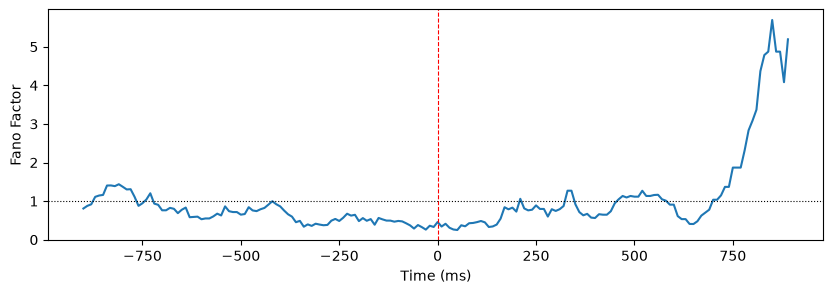

In [5]:
W_ms = 200  # sliding window width in ms

t_centres, ff_d0 = utils.compute_ff_timecourse(data['mo'][0], W_ms, data['t_start_ms'], data['t_stop_ms'])
utils.plot_ff_timecourse(t_centres, ff_d0)


**Exercise**: Compare the time-resolved FF for direction 0 with W = 100, 200, and 400 ms using `utils.plot_ff_compare_windows()`.


**Exercise**: Plot the time-resolved FF for all 6 directions (W = 200 ms, MO-aligned) using `utils.plot_ff_all_directions()`.


**Exercise**: Compare the MO-aligned and TS-aligned FF for direction 0 (W = 200 ms) using `utils.plot_ff_alignment_comparison()`. The two panels have different time axes: MO covers −1000 to +1000 ms (around movement onset) and TS covers 0 to +2000 ms (from trial start). The red dashed line marks t = 0 in each panel, i.e., the respective alignment event. At what time does the FF dip appear in the TS panel, and what physiological quantity does that time estimate?


## Interval and Count Variability

We now directly compare the variability of inter-spike intervals (ISI) with the trial-by-trial count variability. For the broad class of renewal processes, the two variables are linked on expectation by

$$FF \approx CV^2$$

(Cox & Lewis 1966; Nawrot 2010). For the Poisson process, FF = CV2 = Lv = 1. For processes with interval history (non-renewal) this equality is violated (Nawrot 2010; Farkhooi et al. 2009, 2011; Avila-Akerberg & Chacron 2011). Any strong deviation from equality is interpretable with respect to timescale: ISI variability reflects short timescale structure (order of the mean ISI) while the Fano factor reflects long timescale variability (order of the inter-trial interval).

The estimation of CV is hampered by time-varying firing rates within a trial. We therefore use local irregularity measures that compare only consecutive ISI pairs. For any two consecutive inter-spike intervals $ISI$ and $ISI^\prime$ in a single trial, CV2 (Holt et al. 1996; Ponce-Alvarez et al. 2010) defines a local coefficient

$$m = 2\frac{|ISI - ISI^{\prime}|}{ISI + ISI^{\prime}},$$

and CV2 is the average of $m$ across all consecutive pairs and all trials. The related measure Lv (Shinomoto et al. 2003) uses the squared difference instead of the absolute difference. For a stationary Poisson process, CV2 = Lv = 1; for any stationary renewal process, CV2 ≈ Lv ≈ CV. The renewal prediction therefore becomes FF = CV2² ≈ Lv².

We compute both FF and CV2 within a common estimation window W chosen as a pre-movement epoch where the Fano factor is approximately stationary (inspect your FF(t) result from the previous section). The exercises below first verify the renewal prediction with simulations, then test it against real data, and finally address the mechanism behind the excess variability (FF >> CV2²) observed in real cortical data.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`elephant.statistics.isi(st)`** | ISIs for one spike train as a numpy array (ms) |
| **`elephant.statistics.cv2(isi)`** | CV2 for one spike train (Holt et al. 1996) |
| **`utils.count_in_window(sts, t1_ms, t2_ms)`** | Spike counts in [t1, t2) ms across all trials |
| **`np.var(counts) / np.mean(counts)`** | Fano factor from spike counts |
| **`utils.simulate_renewal_trains(rate_hz, shape_factor, n_trains)`** | n Gamma(κ) trains; shape_factor=1 gives Poisson |
| **`utils.simulate_doubly_stochastic(rates_hz)`** | One Poisson train per rate in `rates_hz` |
| **`utils.load_population(data_dir='data/')`** | Load all C1-MO neurons; returns list of dicts |
| **`utils.plot_ff_population_scatter(ff_arr, cv2sq_arr, labels=None)`** | Log-log scatter of FF vs CV2² with renewal diagonal; optional point labels |
| **`utils.plot_ff_with_marginals(ff_arr, cv2sq_arr)`** | Scatter plus marginal histograms |

### Exercises

**Example**: For the single loaded neuron, compute FF and CV2 per direction using the
estimation window W = [-500, 0) ms (pre-movement, approximately stationary). Print a summary table.


In [6]:
W_t0, W_t1 = -500, 0  # estimation window in ms (pre-movement)

print(f"{'Dir':>4}  {'FF':>8}  {'CV2':>8}  {'CV2²':>8}")
ff_single, cv2sq_single = [], []
for d in range(6):
    counts = utils.count_in_window(data['mo'][d], W_t0, W_t1)
    if np.mean(counts) < 0.5:
        continue
    ff = np.var(counts) / np.mean(counts)
    cv2_vals = [elephant.statistics.cv2(elephant.statistics.isi(st))
                for st in data['mo'][d] if len(st) > 3]
    cv2_mean = np.mean(cv2_vals) if cv2_vals else np.nan
    ff_single.append(ff)
    cv2sq_single.append(cv2_mean**2)
    print(f"{d:>4}  {ff:>8.3f}  {cv2_mean:>8.3f}  {cv2_mean**2:>8.3f}")

 Dir        FF       CV2      CV2²
   0     0.438     0.580     0.337
   1     0.897     0.672     0.451
   2     0.757     0.790     0.625
   3     1.344     0.565     0.319
   4     1.385     0.589     0.347
   5     1.147     0.611     0.373


**Exercise**: Plot FF vs CV2² for the 6 directions of this neuron using `utils.plot_ff_population_scatter()`. Pass direction indices as labels. Use `ff_single` and `cv2sq_single` from the example above.


The excess FF >> CV2² points to a source of variability that operates across trialrather than within them. The doubly stochastic model provides a demonstration:
if each trial draws a different firing rate from some distribution, then spikes within
each trial are locally Poisson (CV2 ≈ 1) but trial-to-trial rate variability inflates
the spike count variance and thus FF (Nawrot et al. 2003; Nawrot 2010). Slow fluctuations
in cortical network state across trials provide a plausible biological substrate; attractor
network models have been proposed to account for the excess FF (Deco et al. 2012;
Litwin-Kumar & Doiron 2012; Mazzucato et al. 2015; Rost et al. 2018; Rostami et al. 2024).

**Example**: Simulate 50 Poisson trains, each with a rate drawn uniformly from [10, 30] Hz.

In [7]:
rng   = np.random.default_rng(42)
rates = rng.uniform(10, 30, 50)   # Hz, one rate per trial

sts_ds    = utils.simulate_doubly_stochastic(rates)
counts_ds = np.array([len(st) for st in sts_ds])
ff_ds     = np.var(counts_ds) / np.mean(counts_ds)
print(f'Doubly stochastic (n=50, rates uniform 10-30 Hz): FF = {ff_ds:.3f}')
# FF >> 1 even though every train is locally Poisson


Doubly stochastic (n=50, rates uniform 10-30 Hz): FF = 4.373


**Exercise**: For the doubly stochastic ensemble, compute mean CV2 per trial.
Print FF and mean CV2 together. How does this compare to the Gamma(4) result above?


**Exercise**: Load all available neurons with `utils.load_population()`.
For each neuron and each direction compute FF (in window W) and mean CV2 (per trial, ≥4 spikes).
Collect all (FF, CV2²) pairs in `ff_pop` and `cv2sq_pop`.

Hint: use `utils.count_in_window()` for FF and `elephant.statistics.cv2()` for CV2.


**Exercise**: Plot the population scatter of FF vs CV2² using `utils.plot_ff_population_scatter(ff_arr, cv2sq_arr)`.
Are the data points above or below the renewal diagonal FF = CV2²?


**Exercise**: Display the marginal distributions of FF and CV2² as histograms.
Call `utils.plot_ff_with_marginals(ff_arr, cv2sq_arr)`. Which distribution is broader?


**Exercise**: Compute `np.mean(ff_arr / cv2sq_arr)`. What does a ratio well above 1 imply
about the source of excess spike count variability?


## Bonus

- How does the CV2 behave if calculated in sliding windows? Does it also show the dynamics exhibited by the FF as a function of time?
- Now that you have the data of all neurons available, calculate the average FF per direction across neurons. Is the effect consistent?

## References

Arieli A, Sterkin A, Grinvald A, Aertsen A (1996) Dynamics of ongoing activity: explanation of the large variability in evoked cortical responses. *Science* 273: 1868-1871.

Avila-Akerberg O, Chacron MJ (2011) Nonrenewal spike train statistics: causes and functional consequences on neural coding. *Exp Brain Res* 210: 353-371.

Churchland MM, Yu BM, Ryu SI, Santhanam G, Shenoy KV (2006) Neural variability in premotor cortex provides a signature of motor preparation. *J Neurosci* 26: 3697-3712.

Churchland MM et al. (2010) Stimulus onset quenches neural variability: a widespread cortical phenomenon. *Nat Neurosci* 13: 369-378.

Churchland AK et al. (2011) Variance as a signature of neural computations during decision making. *Neuron* 69: 818-831.

Cox DR, Lewis PAW (1966) *The statistical analysis of series of events.* Chapman & Hall, London.

Deco G, Hugues E (2012) Neural network mechanisms underlying stimulus driven variability reduction. *PLoS Comput Biol* 8: e1002395.

Farkhooi F, Strube-Bloss MF, Nawrot MP (2009) Serial correlation in neural spike trains. *Phys Rev E* 79: 021905.

Farkhooi F, Muller E, Nawrot MP (2011) Adaptation reduces variability of the neuronal population code. *Phys Rev E* 83: 050905.

Holt GR, Softky WR, Koch C, Douglas RJ (1996) Comparison of discharge variability in vitro and in vivo in cat visual cortex neurons. *J Neurophysiol* 75: 1806-1814.

Litwin-Kumar A, Doiron B (2012) Slow dynamics and high variability in balanced cortical networks with clustered connections. *Nat Neurosci* 15: 1498-1505.

Mazzucato L, Fontanini A, La Camera G (2015) Dynamics of multistable states during ongoing and evoked cortical activity. *J Neurosci* 35: 8214-8231.

Nawrot MP (2010) Analysis and interpretation of interval and count variability in neural spike trains. In: Grün S, Rotter S (eds) *Analysis of parallel spike trains.* Springer, New York, pp 34-58.

Nawrot MP, Riehle A, Aertsen A, Rotter S (2003) Variability of motor cortical activity explained by network dynamics on multiple time scales. In: *Ongoing activity in cortical networks: noise, variability and context* (PhD thesis), URN: nbn:de:bsz:25-opus-73426.

Nawrot MP et al. (2008) Measurements of variability dynamics in cortical spike trains. *J Neurosci Meth* 169: 374-390.

Ponce-Alvarez A, Kilavik BE, Riehle A (2010) Comparison of local measures of spike time irregularity and relating variability to firing rate in motor cortical neurons. *J Comput Neurosci* 29: 351-365.

Rickert J, Riehle A, Aertsen A, Rotter S, Nawrot MP (2009) Dynamic encoding of movement direction in motor cortical neurons. *J Neurosci* 29: 13870-13882.

Riehle A, Brochier T, Nawrot M, Grün S (2018) Behavioral context determines network state and variability dynamics in monkey motor cortex. *Front Neural Circuits* 12: 52.

Rost T, Deger M, Nawrot MP (2018) Winnerless competition in clustered balanced networks. *Biol Cybern* 112: 81-98.

Rostami V, Rost T, Schmitt FJ, van Albada SJ, Riehle A, Nawrot MP (2024) Spiking attractor model of motor cortex explains modulation of neural and behavioral variability by prior target information. *Nat Commun* 15: 6304.

Shadlen MN, Newsome WT (1998) The variable discharge of cortical neurons. *J Neurosci* 18: 3870-3896.

Shinomoto S, Shima K, Tanji J (2003) Differences in spiking patterns among cortical neurons. *Neural Comput* 15: 2823-2842.

---

**Further Reading**

Riehle A, Vaadia E (eds, 2005) *Motor Cortex in Voluntary Movements.* CRC Press, Boca Raton.